# 密度估计 benchmark：准确度、稳定性与时间成本

这个 notebook 比较三种连续密度估计方案：`transport_map`、`kde` 与 `knn`。本次展示只围绕三个问题组织：

1. **准确度**：估计的 `log p` 是否接近解析真值；
2. **稳定性 / 收敛性**：重复实验的波动是否小，样本量增加后误差是否下降并趋于平稳；
3. **时间花销**：拟合和打分的总时间是否可接受。

主指标采用 `RMSE(log p)`，因为三个数据族都有解析 log-density，可以直接衡量密度估计误差；`KL(p || p_hat)` 作为偏差方向的辅助指标，`held-out NLL` 保留在缓存中但不作为主图焦点。


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd().resolve() / "tmp" / "matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "utils.py").exists():
        PROJECT_ROOT = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    PROJECT_ROOT = Path.cwd().resolve()

import pandas as pd
from IPython.display import Image, display

from density_benchmark import (
    DensityBenchmarkConfig,
    DensityPlotConfig,
    compact_accuracy_table,
    load_or_run_density_benchmark,
    plot_density_benchmark_composite,
)


## 实验设计

三类数据族分别覆盖线性高斯、双峰混合分布和非线性 banana warp。默认准确度实验固定 `d = 8`、`n_train = 2000`，重复 `10` 次；鲁棒性扫描固定同一测试集规模，分别扫描维度和训练样本量，每个配置重复 `8` 次。

这样的设计把“平均准确度”和“重复实验是否收敛”分开看：如果一个方法均值低但误差带宽，说明表现不稳定；如果样本量增加后 `RMSE(log p)` 不再明显下降，说明在当前设置下已经接近收敛平台。


In [2]:
EXPERIMENT_CONFIG = DensityBenchmarkConfig(
    cache_dir=PROJECT_ROOT / "exp" / "cache" / "density_benchmark",
    fig_dir=PROJECT_ROOT / "fig" / "transport_map_mutual_information",
    families=("gaussian", "gmm", "banana"),
    accuracy_repeats=10,
    scan_repeats=8,
    accuracy_dim=8,
    scan_dim=8,
    n_train=2000,
    n_test=2000,
    total_dims=(2, 4, 8, 16),
    sample_sizes=(200, 500, 1000, 2000),
    seed=7,
)

PLOT_CONFIG = DensityPlotConfig(
    fig_dir=EXPERIMENT_CONFIG.fig_dir,
    basename="density_benchmark_composite",
    formats=("png", "pdf"),
)


## 运行或读取缓存

长实验会先把每次重复的 raw 结果和汇总表落盘到 `exp/cache/density_benchmark/`。后续执行会检查配置签名；只要配置没有变化，默认直接读取缓存。若需要强制重跑，把下面的 `force=False` 改为 `force=True`。


In [3]:
density_benchmark_results = load_or_run_density_benchmark(
    config=EXPERIMENT_CONFIG,
    force=False,
)

accuracy_table = compact_accuracy_table(density_benchmark_results["accuracy_summary"])
display(accuracy_table.style.format(precision=4))


,family_title,method,n_repeats,rmse_log_density_mean,rmse_log_density_sem,kl_p_phat_mean,kl_p_phat_sem,total_time_mean
0,Banana,KDE,10,0.8516,0.0113,0.3668,0.0066,0.1622
1,Banana,kNN,10,0.6719,0.0065,-0.0116,0.0070,0.0271
2,Banana,Transport map,10,0.5776,0.0088,0.1202,0.0031,0.0003
3,Gaussian,KDE,10,0.8117,0.0077,0.3765,0.0096,0.1624
4,Gaussian,kNN,10,0.7312,0.0044,0.0564,0.0093,0.0238
5,Gaussian,Transport map,10,0.1478,0.0037,0.0117,0.0013,0.0003
6,Gaussian mixture,KDE,10,0.8030,0.0055,0.3677,0.0060,0.1617
7,Gaussian mixture,kNN,10,0.7325,0.0070,0.0489,0.0075,0.0234
8,Gaussian mixture,Transport map,10,0.2593,0.0044,0.0342,0.0020,0.0003


## 主结果图

图 a 是主证据：`RMSE(log p)` 越低，说明估计密度越接近解析真值。图 b 用 `KL(p || p_hat)` 检查系统性偏差。图 d 和 e 用均值曲线与标准误差带展示收敛和维度鲁棒性。图 c 只作为成本约束，用 log 轴展示总时间，避免时间差异压过准确度判断。


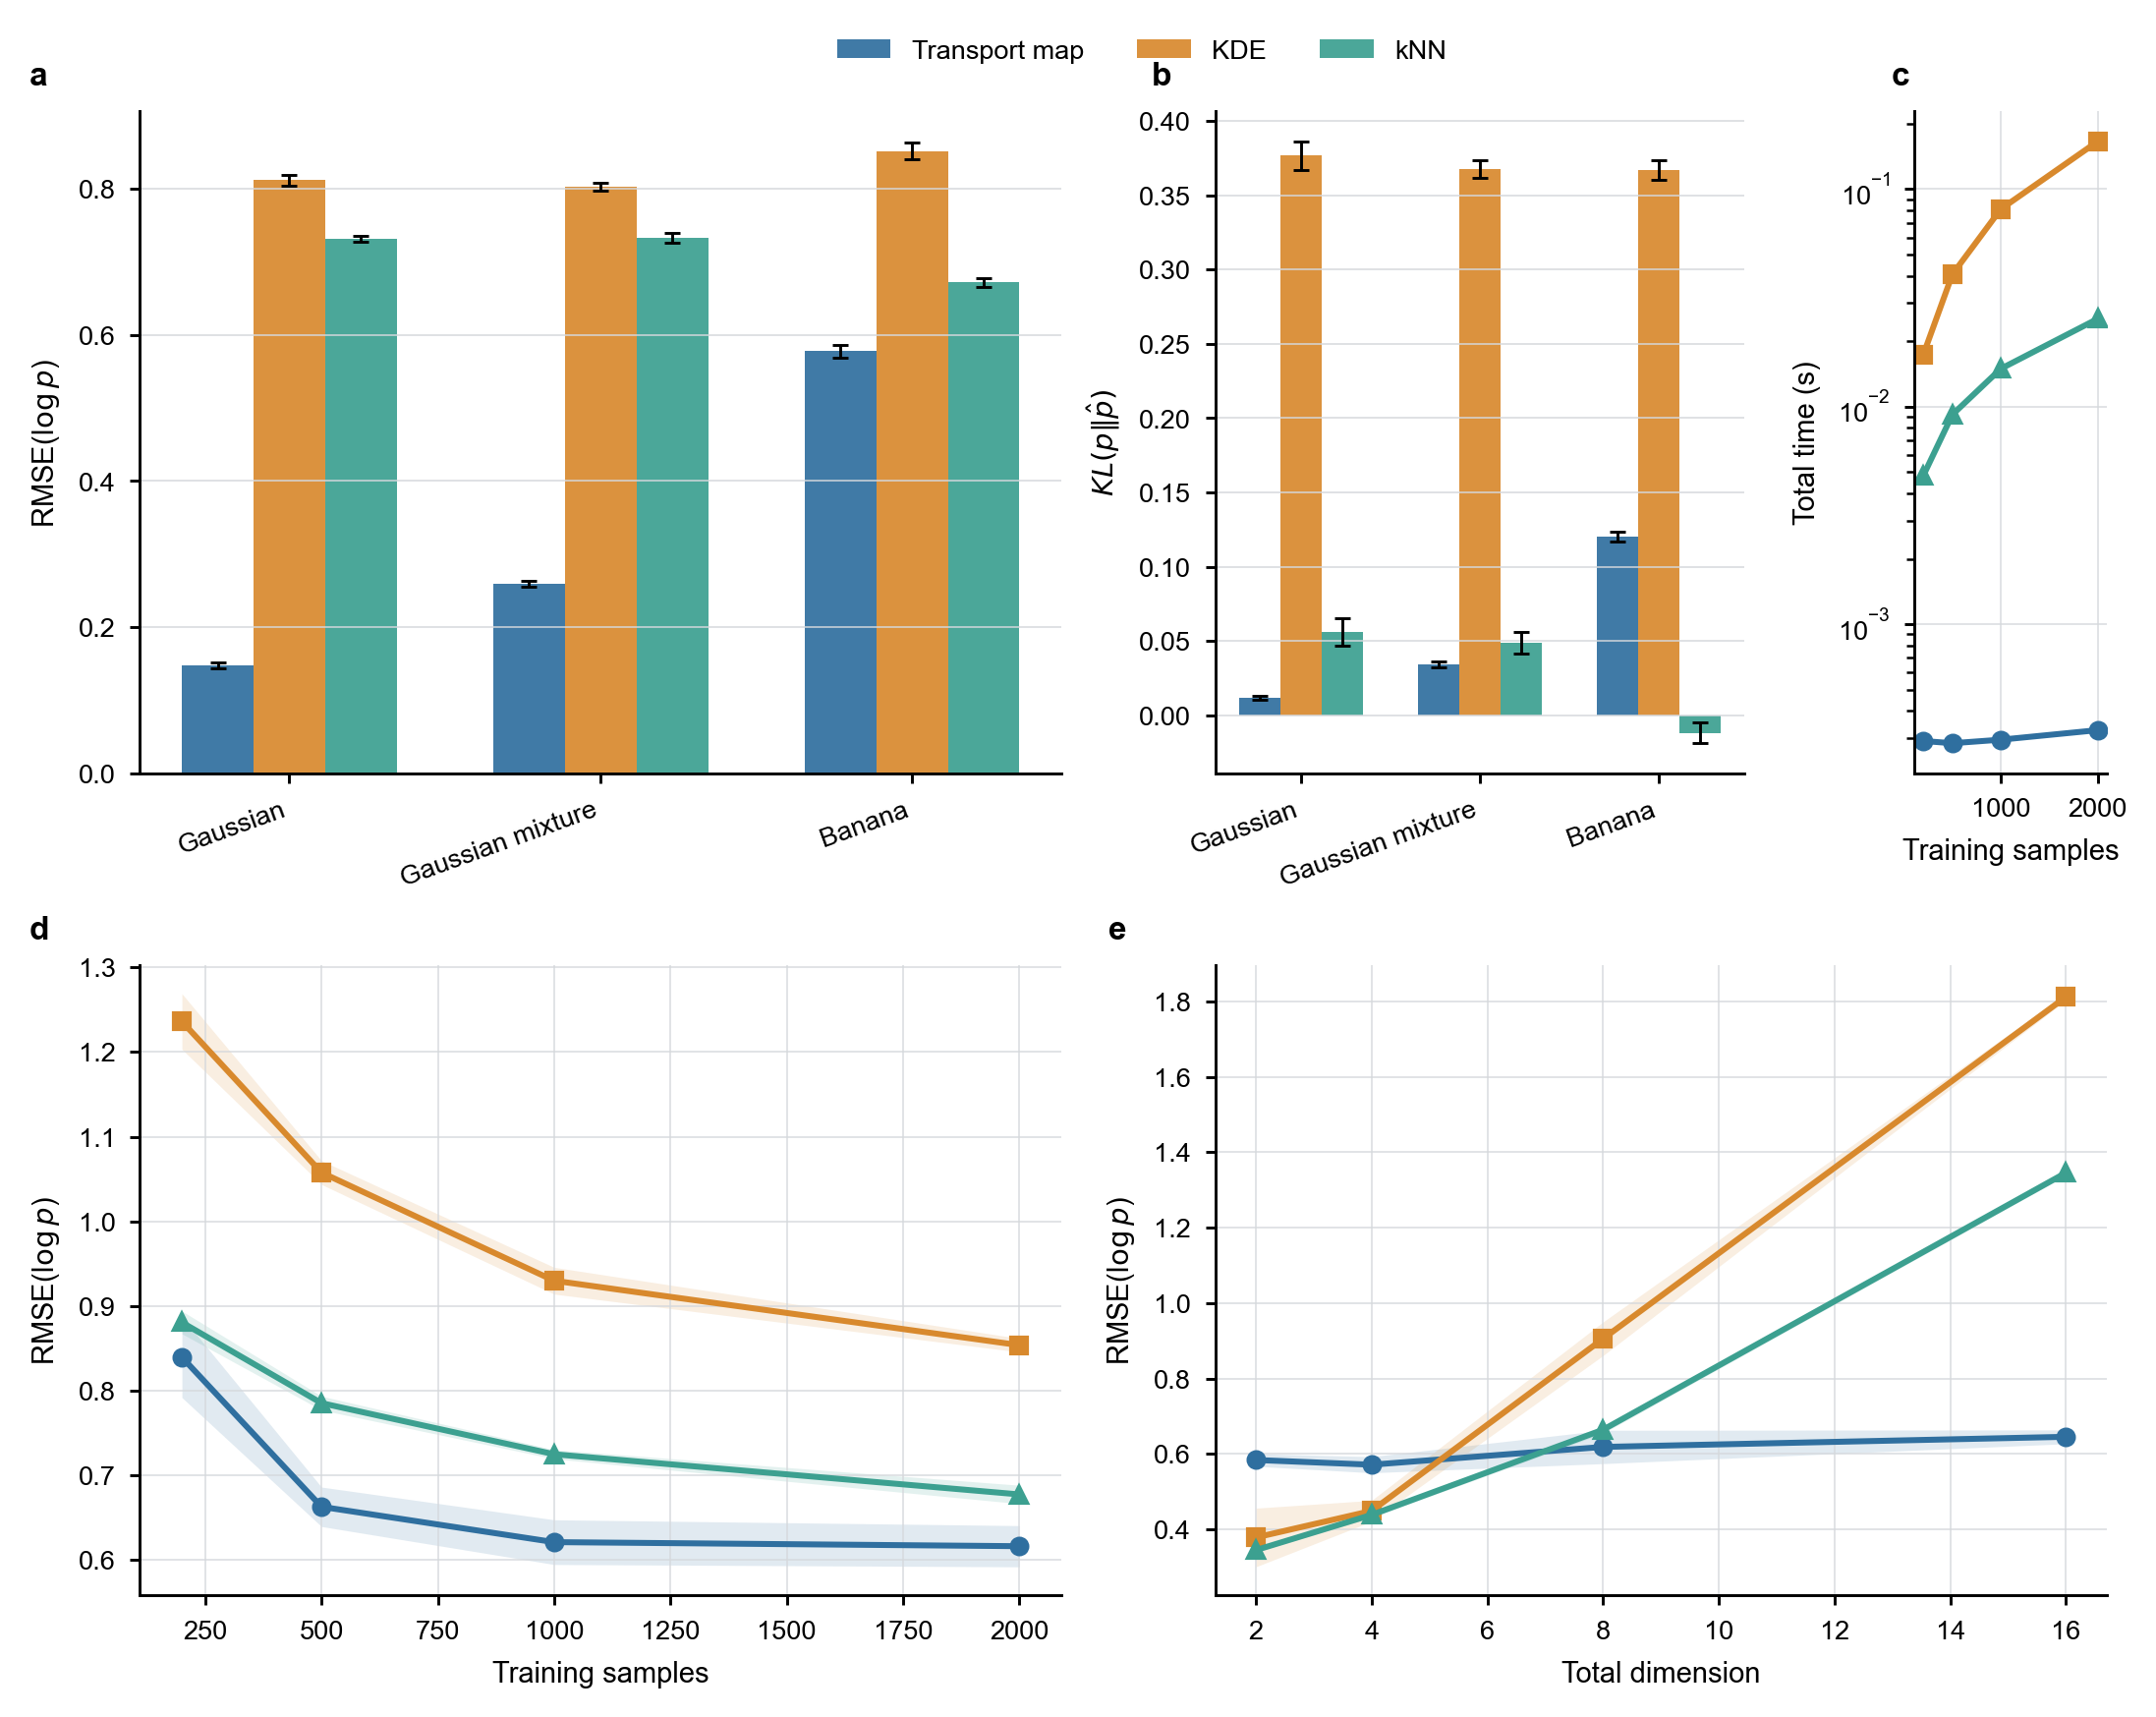

[PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/density_benchmark_composite.png'),
 PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/density_benchmark_composite.pdf')]

In [4]:
figure_paths = plot_density_benchmark_composite(
    density_benchmark_results,
    plot_config=PLOT_CONFIG,
)

png_path = next(path for path in figure_paths if path.suffix == ".png")
display(Image(filename=str(png_path)))
figure_paths


## 结果解读

这组 benchmark 的核心判断应优先看 `RMSE(log p)`：它直接比较估计 log-density 和解析真值，能反映密度形状是否被学准。重复实验的标准误差越窄，说明随机采样下的结果越稳定；样本量曲线若随 `n_train` 增加下降并趋于平缓，说明该方法在当前数据族上逐步收敛。

时间图只回答成本问题：即使某个方法准确度相近，若总时间高出一个数量级，在后续大规模连续变量实验中也会成为瓶颈。最终结论应同时满足三点：准确度足够低、重复波动可控、时间成本没有明显失控。


## 局限与后续扩展

当前 transport-map 基线是仿射下三角估计器，因此对高斯族最匹配；banana 和 GMM 更能暴露非线性或多峰场景下的偏差。若要更贴近论文中的一般 transport map，需要替换为更高阶的非线性 triangular map，并保留同样的缓存、重复实验和主图结构。


## 输出约定

- 缓存文件写到 `exp/cache/density_benchmark/`；
- 主图写到 `fig/transport_map_mutual_information/density_benchmark_composite.png` 和 `.pdf`；
- manifest 记录当前配置签名，配置变化后会自动重跑。
